# Introduction

In [1]:
# Import spacy
import spacy

# Install English language model
!spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 10.5 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 12.4 MB/s eta 0:00:01
     --------------------- ------------------ 6.8/12.8 MB 12.3 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 12.2 MB/s eta 0:00:01
     ------------------------------------ -- 12.1/12.8 MB 12.4 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 12.3 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 12.3 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 12.3 MB/s eta 0:00:01
     --------------------------------------  12.6/12.8 MB 12.3 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.7 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
# Import os to upload documents and metadata
import os

# Load spaCy visualizer
from spacy import displacy

# Import pandas DataFrame packages
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'

# Import graphing package
import plotly.express as px

In [3]:
# Install gutenberg-cleaner package for cleaning gutenberg texts

In [4]:
pip install gutenberg-cleaner

Note: you may need to restart the kernel to use updated packages.


# Description

In [5]:
# Create empty lists for file names and contents
texts = []
file_names = []

# Iterate through each file in the folder
for _file_name in os.listdir('Dataset'):
# Look for only text files
    if _file_name.endswith('.txt'):
    # Append contents of each text file to text list
        texts.append(open('Dataset' + '/' + _file_name, 'r', encoding='utf-8').read())
        # Append name of each file to file name list
        file_names.append(_file_name)

In [6]:
# Create dictionary object associating each file name with its text
d = {'Filename':file_names,'Text':texts}

In [7]:
# Import simple_cleaner module from gutenberg-cleaner
from gutenberg_cleaner import simple_cleaner

# Clean each text using the simple_cleaner
d['Text'] = [simple_cleaner(text) for text in d['Text']]


In [8]:
# Turn dictionary into a dataframe
text_df = pd.DataFrame(d)

In [9]:
text_df.head()

,Filename,Text
0,19978.txt,\r\n\r\n\r\n\r\n35 Sonnets\r\n\r\nby Fernando ...
1,66039.txt,\r\nENGLISH\r\nPOEMS\r\n\r\n\r\n\r\n\r\nBY\r\n...
2,66040.txt,ENGLISH\r\nPOEMS\r\n\r\n\r\n\r\n\r\nBY\r\nFERN...


In [10]:
# Remove unwanted characters from the text. Preserve new line characters in order to normalize the beginnings of each line in the corpus.
# This will help at a later stage when we need to extract the part-of-speech and proper names from the corpus.
text_df['Text'] = text_df['Text'].str.replace('\r', ' ', regex=True).str.strip()
text_df['Text'] = text_df['Text'].str.replace('\t', ' ', regex=True).str.strip()

In [11]:
# Remove .txt from title of each paper
text_df['Filename'] = text_df['Filename'].str.replace('.txt', '', regex=True)
text_df.head()

,Filename,Text
0,19978,35 Sonnets \n \nby Fernando Pessoa \n \n \n \n...
1,66039,ENGLISH \nPOEMS \n \n \n \n \nBY \n \nFERNANDO...
2,66040,ENGLISH \nPOEMS \n \n \n \n \nBY \nFERNANDO PE...


In [12]:
# Define a function that will lowercase the first character of the first word in every line of the text, preserving any leading whitespace (e.g., spaces or tabs).

def decapitalize_line_starts_with_indentation(text):
    lines = text.split('\n')  # Split text into individual lines
    normalized_lines = []
    
    for line in lines:
        stripped_line = line.lstrip()  # Remove leading whitespace temporarily
        if stripped_line:  # Check if the line is not empty
            normalized_line = stripped_line[:1].lower() + stripped_line[1:]  # Lowercase the first char
            # Re-add the leading whitespace to keep the format of the poem as intended
            normalized_lines.append(line[:len(line) - len(stripped_line)] + normalized_line)
        else:
            # For empty lines, keep them as they are
            normalized_lines.append(line)
    
    return '\n'.join(normalized_lines)  # Rejoin lines into a single string

# Apply the function to the dataframe
text_df['Text'] = text_df['Text'].apply(decapitalize_line_starts_with_indentation)

# Print one full normalized text to see the results
print("Normalized Text Example:")
print(text_df.loc[0, 'Text']) 

Normalized Text Example:
35 Sonnets 
 
by Fernando Pessoa 
 
 
 
 
i. 
 
 
whether we write or speak or do but look 
we are ever unapparent. What we are 
cannot be transfused into word or book. 
our soul from us is infinitely far. 
however much we give our thoughts the will 
to be our soul and gesture it abroad, 
our hearts are incommunicable still. 
in what we show ourselves we are ignored. 
the abyss from soul to soul cannot be bridged 
by any skill of thought or trick of seeming. 
unto our very selves we are abridged 
when we would utter to our thought our being. 
    we are our dreams of ourselves, souls by gleams, 
    and each to each other dreams of others’ dreams. 
 
 
 
 
iI. 
 
 
if that apparent part of life’s delight 
our tingled flesh-sense circumscribes were seen 
by aught save reflex and co-carnal sight, 
joy, flesh and life might prove but a gross screen. 
haply Truth’s body is no eyable being, 
appearance even as appearance lies, 
haply our close, dark, vague, warm sen

Upon inspecting the results we will see that further processing is needed to account for mid-line cases where new sentences start. For now the result is satisfacatory the way it is. We can proceed with loading the metadata for the three texts in our corpus. This can be done by downloading the metadata .csv file from the Gutenberg website and writing some  code that will select only the metadata that is relevant to our case.

In [13]:
# Load the Gutenberg metadata csv
metadata_df = pd.read_csv('pg_catalog.csv')

# List of Gutenberg IDs for the chosen books
chosen_book_ids = [19978, 66039, 66040]  # Extract only the metadata for the three texts by Pessoa in our corpus

# Filter the DataFrame to include only rows with these IDs
filtered_metadata = metadata_df[metadata_df['Text#'].isin(chosen_book_ids)]

# Display the filtered metadata
print(filtered_metadata)

# Save the filtered metadata to a new CSV
filtered_metadata.to_csv('pessoa_metadata.csv', index=False)


       Text#  Type      Issued                            Title Language  \
19907  19978  Text  2006-11-30                       35 Sonnets       en   
65960  66039  Text  2021-08-11  English Poems, Volume 01 (of 2)       en   
65961  66040  Text  2021-08-11  English Poems, Volume 02 (of 2)       en   

                           Authors Subjects LoCC  \
19907  Pessoa, Fernando, 1888-1935   Poetry   PQ   
65960  Pessoa, Fernando, 1888-1935   Poetry   PQ   
65961  Pessoa, Fernando, 1888-1935   Poetry   PQ   

                                  Bookshelves  
19907  Browsing: Literature; Browsing: Poetry  
65960  Browsing: Literature; Browsing: Poetry  
65961  Browsing: Literature; Browsing: Poetry  


In [14]:
# Assign the newly created pessoa_metadata.csv to the metadata dataframe
metadata_df = pd.read_csv('pessoa_metadata.csv')
metadata_df.head()

,Text#,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
0,19978,Text,2006-11-30,35 Sonnets,en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry
1,66039,Text,2021-08-11,"English Poems, Volume 01 (of 2)",en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry
2,66040,Text,2021-08-11,"English Poems, Volume 02 (of 2)",en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry


In order to merge the two DataFrames that we have created until this point we need to create a common column upon which the merge will be executed. Let's rename the 'Text#' column in our metadata_df to 'Filename' in order to match the 'Filename' column in the text_df. Another issue that we need to take care of before merging is that the data for 'Text#' in our .csv file downloaded from Gutenberg is integer while the one in 'Title' column in our text_df is a string. To solve this we will convert the datatype in our metadata_df to strings. 

In [15]:
# Rename column from Title to Filename in order to merge the two tables
metadata_df.rename(columns={"Text#": "Filename"}, inplace=True)
metadata_df.head()

,Filename,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves
0,19978,Text,2006-11-30,35 Sonnets,en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry
1,66039,Text,2021-08-11,"English Poems, Volume 01 (of 2)",en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry
2,66040,Text,2021-08-11,"English Poems, Volume 02 (of 2)",en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry


In [16]:
# Convert the data type of the Filename column into strings to allow the merging of the metadata and text tables in the next step
metadata_df['Filename'] = metadata_df['Filename'].astype(str)

In [17]:
# Merge the files to their metadata in a new DataFrame
pessoa_df = metadata_df.merge(text_df,on='Filename')
pessoa_df.head()

,Filename,Type,Issued,Title,Language,Authors,Subjects,LoCC,Bookshelves,Text
0,19978,Text,2006-11-30,35 Sonnets,en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry,35 Sonnets \n \nby Fernando Pessoa \n \n \n \n...
1,66039,Text,2021-08-11,"English Poems, Volume 01 (of 2)",en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry,eNGLISH \npOEMS \n \n \n \n \nbY \n \nfERNANDO...
2,66040,Text,2021-08-11,"English Poems, Volume 02 (of 2)",en,"Pessoa, Fernando, 1888-1935",Poetry,PQ,Browsing: Literature; Browsing: Poetry,eNGLISH \npOEMS \n \n \n \n \nbY \nfERNANDO PE...


After merging the two dataframes we can start with processing the content of our DataFrames using spaCy. See the Notebook at https://github.com/yevgenm/corpus-analysis-spacy/ for a detailed description of all the steps that are performed in the following lines of code.

In [18]:
# Load nlp pipeline
nlp = spacy.load('en_core_web_sm')

# Check what functions it performs
print(nlp.pipe_names)

['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [19]:
# Define a function that runs the nlp pipeline on any given input text
def process_text(text):
    return nlp(text)

In [20]:
# Apply the function to the "Text" column, so that the nlp pipeline is called on each of the three Pessoa works in our corpus
pessoa_df['Doc'] = pessoa_df['Text'].apply(process_text)

In [21]:
# Define a function to retrieve tokens from a doc object
def get_token(doc):
    return [(token.text) for token in doc]

In [22]:
# Run the token retrieval function on the doc objects in the dataframe
pessoa_df['Tokens'] = pessoa_df['Doc'].apply(get_token)

In [23]:
# Define a function to retrieve lemmas from a doc object
def get_lemma(doc):
    return [(token.lemma_) for token in doc]

# Run the lemma retrieval function on the doc objects in the dataframe
pessoa_df['Lemmas'] = pessoa_df['Doc'].apply(get_lemma)

In [24]:
# Define a function to retrieve parts-of-speech (pos) from a doc object
def get_pos(doc):
    #Return the coarse- and fine-grained part of speech text for each token in the doc
    return [(token.pos_, token.tag_) for token in doc]

# Define a function to retrieve parts of speech from a doc object
pessoa_df['POS'] = pessoa_df['Doc'].apply(get_pos)

In [25]:
# Define function to extract named entities from doc objects
def extract_named_entities(doc):
    return [ent.label_ for ent in doc.ents]
# Apply function to Doc column and store resulting named entities in a new column
pessoa_df['Named_Entities'] = pessoa_df['Doc'].apply(extract_named_entities)
pessoa_df['Named_Entities']
# Apply function to Doc column and store resulting named entities foudn in the corpus in a new column
pessoa_df['NE_Words'] = pessoa_df['Doc'].apply(extract_named_entities)
pessoa_df['NE_Words']

0    [CARDINAL, ORG, PERSON, ORG, ORG, PERSON, DATE...
1    [CARDINAL, DATE, DATE, ORG, ORG, PERSON, DATE,...
2    [CARDINAL, DATE, DATE, PERSON, TIME, DATE, CAR...
Name: NE_Words, dtype: object

In [26]:
# Extract the first Doc object
doc = pessoa_df['Doc'][2]

# Visualize named entity tagging in the '35 Sonnets' text by Pessoa
displacy.render(doc, style='ent', jupyter=True)

In [27]:
# Create new DataFrame for analysis purposes
pos_analysis_df = pessoa_df[['Filename','Title', 'Doc']]

# Create list to store each dictionary
num_list = []

# Define a function to get part of speech tags and counts and append them to a new dictionary
def get_pos_tags(doc):
    dictionary = {}
    num_pos = doc.count_by(spacy.attrs.POS)
    for k,v in sorted(num_pos.items()):
        dictionary[doc.vocab[k].text] = v
    num_list.append(dictionary)

# Apply function to each doc object in DataFrame
pos_analysis_df.loc['C_POS'] = pos_analysis_df['Doc'].apply(get_pos_tags)

In [28]:
# Create new dataframe with part of speech counts
pos_counts = pd.DataFrame(num_list)
columns = list(pos_counts.columns)

# Add each text as new column to dataframe
idx = 0
new_col = pos_analysis_df['Title']
pos_counts.insert(loc=idx, column='Title', value=new_col)

pos_counts

,Title,ADJ,ADP,ADV,AUX,CCONJ,DET,INTJ,NOUN,NUM,PART,PRON,PROPN,PUNCT,SCONJ,VERB,X,SPACE,SYM
0,35 Sonnets,351,456,162,235,184,345,3,918,10,179,495,99,630,137,582,6,526,NaN
1,"English Poems, Volume 01 (of 2)",293,355,206,196,154,290,4,848,17,123,431,94,537,76,459,10,458,1.0
2,"English Poems, Volume 02 (of 2)",240,307,136,98,141,300,4,731,9,103,276,46,382,79,416,11,409,NaN


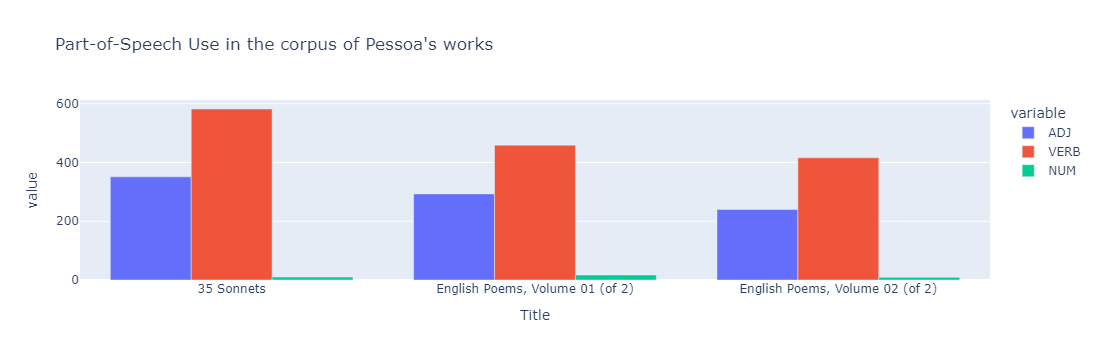

In [34]:
# Use plotly to plot part-of-speech use per text
fig = px.bar(pos_counts, x="Title", y=["ADJ", 'VERB', "NUM"], title="Part-of-Speech Use in the corpus of Pessoa's works", barmode='group')
fig.show()

In [30]:
# Create new DataFrame for analysis purposes
ner_analysis_df = pessoa_df[['Filename','Title', 'Named_Entities', 'NE_Words']]

In [31]:
# Convert named entity lists to strings so we can count specific entities
ner_analysis_df['Named_Entities'] = ner_analysis_df['Named_Entities'].apply(lambda x: ' '.join(x))

# Get the number of each type of entity in each paper
person_counts = ner_analysis_df['Named_Entities'].str.count('PERSON')
loc_counts = ner_analysis_df['Named_Entities'].str.count('LOC')
woa_counts = ner_analysis_df['Named_Entities'].str.count('WORK_OF_ART')

# Append named entity counts to new DataFrame
ner_counts_df = pd.DataFrame()
ner_counts_df['Filename'] = ner_analysis_df["Title"]
ner_counts_df['PERSON_Counts'] = person_counts
ner_counts_df['LOC_Counts'] = loc_counts
ner_counts_df['WORK_OF_ART_Counts'] = woa_counts

ner_counts_df.head()

,Filename,PERSON_Counts,LOC_Counts,WORK_OF_ART_Counts
0,35 Sonnets,14,0,5
1,"English Poems, Volume 01 (of 2)",20,4,4
2,"English Poems, Volume 02 (of 2)",5,2,1


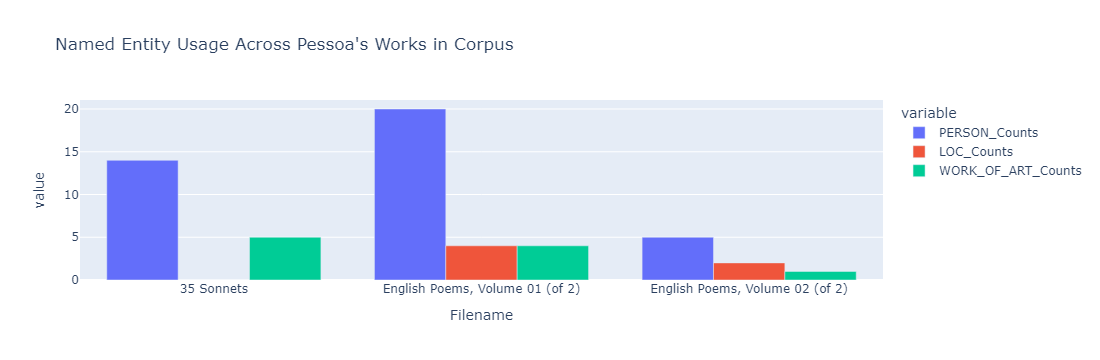

In [32]:
# Use plotly to plot proper noun use per work in corpus
fig = px.bar(ner_counts_df, x="Filename", y=["PERSON_Counts", 'LOC_Counts', 'WORK_OF_ART_Counts'], title="Named Entity Usage Across Pessoa's Works in Corpus", barmode='group')
fig.show()

# Saving the DataFrame as CSV

In [33]:
# Save DataFrame as csv to your computer's working directory
pessoa_df.to_csv('Pessoa_Corpus_with_spaCy_tags.csv')